# Step 1 – Load and Inspect the Data

# Project Title
Netflix Movies and TV Shows Data Analysis

# Introduction
This project performs Exploratory Data Analysis (EDA) on the Netflix Movies and TV Shows dataset from Kaggle to identify trends, patterns, and business insights.

In [33]:
import kagglehub

path = kagglehub.dataset_download("shivamb/netflix-shows")

print(path)

Using Colab cache for faster access to the 'netflix-shows' dataset.
/kaggle/input/netflix-shows


In [34]:
import os

print(os.listdir(path))

['netflix_titles.csv']


In [35]:
import pandas as pd
import os

csv_file = os.path.join(path, "netflix_titles.csv")
df = pd.read_csv(csv_file)

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [36]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nFirst 5 Rows:")
print(df.head())

Shape: (8807, 12)

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicate Rows:
0

First 5 Rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory            

# Step 2 – Data Cleaning

In [37]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')

# Convert date column
df['date_added'] = pd.to_datetime(
    df['date_added'],
    format='mixed',
    errors='coerce'
)

print(df.isnull().sum())

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64


In [38]:
print(df['date_added'].head())
print(df.isnull().sum())

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64


In [39]:
df['duration'] = df['duration'].fillna('Unknown')

In [40]:
print(df.isnull().sum())

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64


# Step 3 – Exploratory Data Analysis

In [41]:
print(df['type'].value_counts())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [42]:
print(df['country'].value_counts().head(10))

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [43]:
print(df['rating'].value_counts())

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
66 min         1
74 min         1
84 min         1
Name: count, dtype: int64


In [44]:
print(df['date_added'].dt.year.value_counts().sort_index())

date_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64


In [45]:
genres = df['listed_in'].str.split(',').explode()
print(genres.value_counts().head(10))

listed_in
 International Movies     2624
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     774
 Independent Movies        736
 TV Dramas                 696
 Romantic Movies           613
Name: count, dtype: int64


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 4 – Visualizations

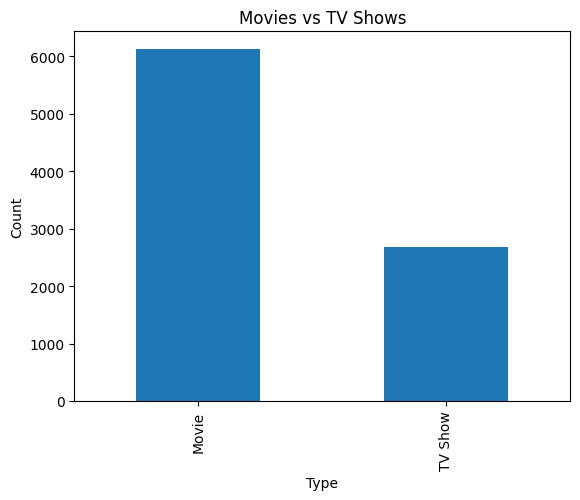

In [47]:
df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

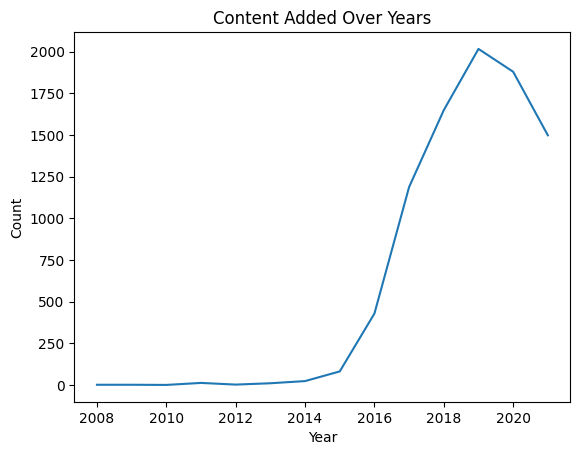

In [48]:
df['date_added'].dt.year.value_counts().sort_index().plot(kind='line')
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

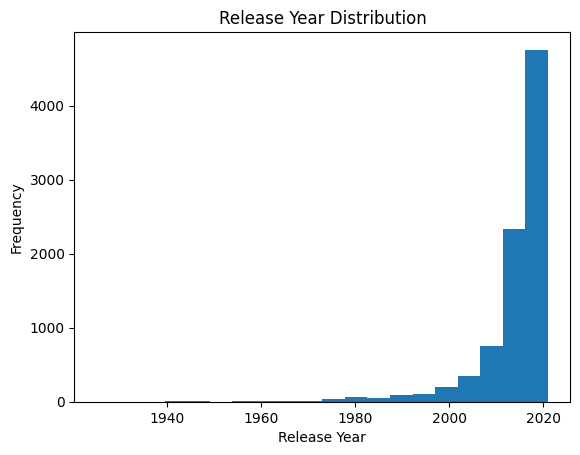

In [49]:
plt.hist(df['release_year'], bins=20)
plt.title("Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

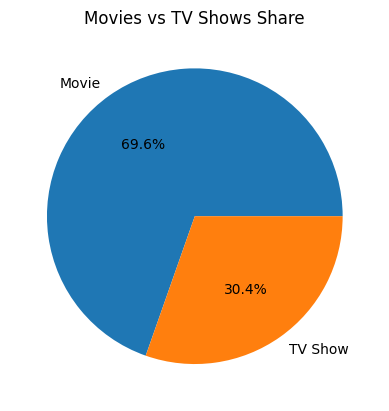

In [50]:
df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Movies vs TV Shows Share")
plt.ylabel("")
plt.show()

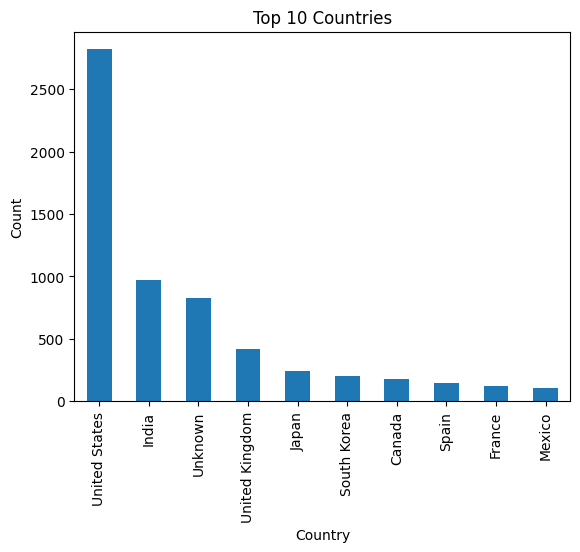

In [51]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

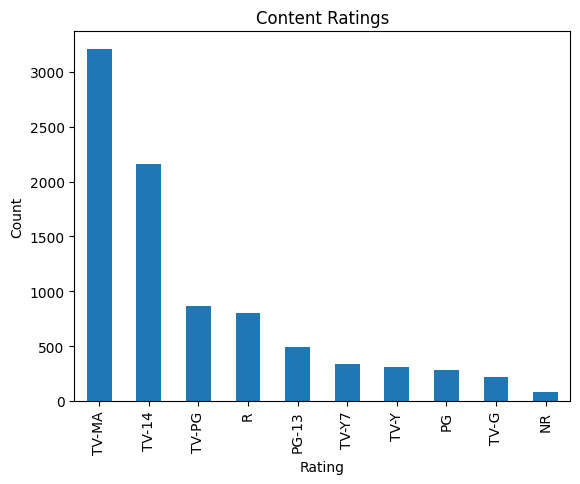

In [52]:
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title("Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

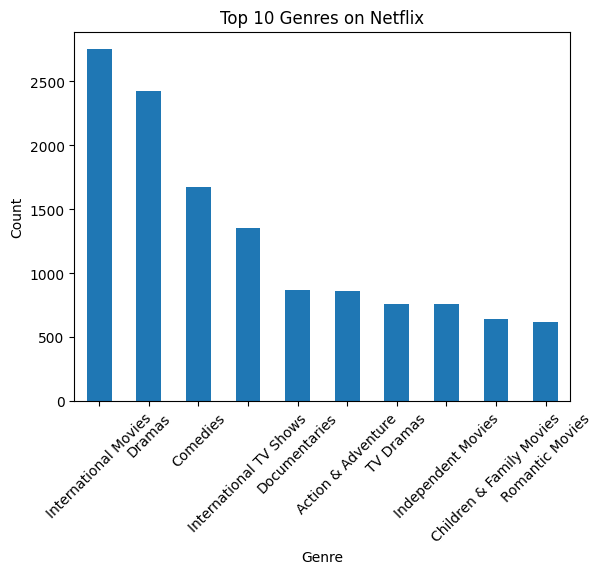

In [53]:
genres = df['listed_in'].str.split(',').explode()

genres = genres.str.strip()

genres.value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# step5- Insights Report



##Insight 1
Movies constitute a larger share of Netflix content than TV Shows, indicating that Netflix focuses more on movie production and acquisition.

## Insight 2
The United States is the leading contributor of content on Netflix, followed by other major entertainment-producing countries.

## Insight 3
The number of titles added to Netflix increased significantly after 2015, showing rapid platform growth.

## Insight 4
TV-MA and TV-14 are the most common ratings, suggesting that Netflix primarily targets mature audiences.

## Insight 5
The Top 10 Genres chart shows that Drama, International Movies, and Comedy are among the most common genres on Netflix. This indicates strong audience demand for diverse and globally appealing content.

# Conclusion

This project analyzed the Netflix Movies and TV Shows dataset to understand content trends, ratings distribution, genre popularity, and platform growth. The analysis revealed that movies dominate Netflix's content library, the United States contributes the largest amount of content, and content additions increased significantly after 2015. Drama, International Movies, and Comedy emerged as some of the most common genres, while TV-MA and TV-14 were the most frequent ratings. These findings provide valuable insights into Netflix's content strategy and audience preferences.

# Most Surprising Finding

The most surprising finding was the rapid increase in Netflix content additions after 2015. The growth was much larger than expected and reflects Netflix's aggressive global expansion strategy. Another interesting observation was that movies significantly outnumber TV shows, despite the increasing popularity of streaming series. This highlights the important role that movies continue to play in Netflix's content catalog.